In [1]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset

In [6]:
from read_outputs import read_results, load_mc_harm_estimates, judge_threshold_ablation, make_log_log_plots

model_outputs/Llama-3.2-1B-Instruct
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'ablation_intensity', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 'model_name', 'base_model_name', 'model_idx', 'cheap_judge', 'use_cache', 'save_output', 'smc_verbose', 'output_dir', 'timestamp'])
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'adapter_name', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 

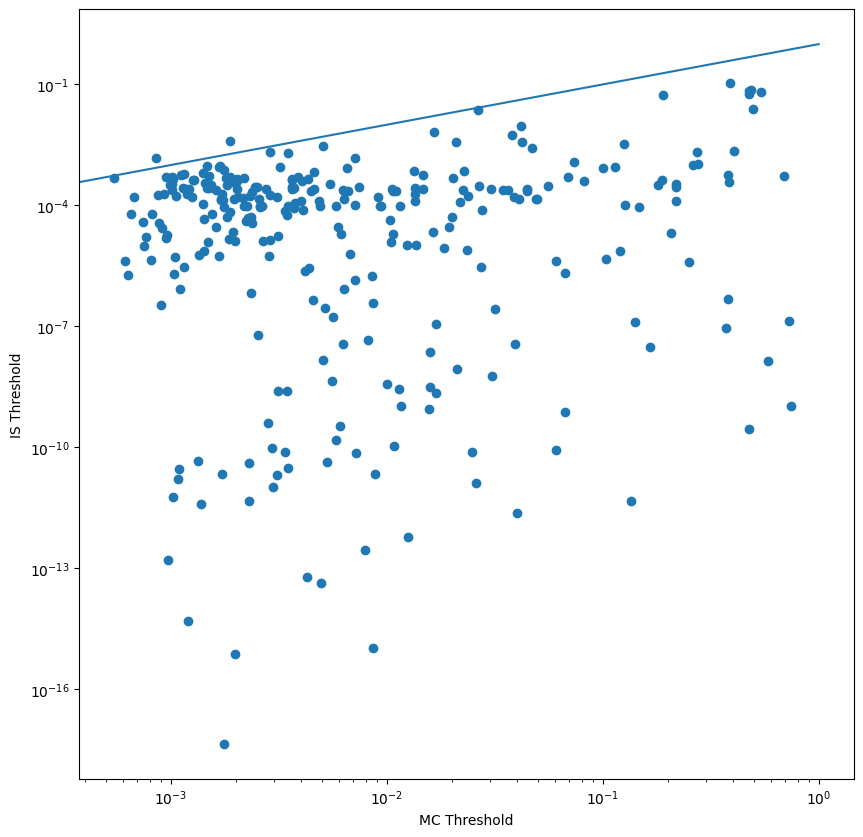

model_outputs/gemma-2-9b-it
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'ablation_intensity', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 'model_name', 'base_model_name', 'model_idx', 'cheap_judge', 'use_cache', 'save_output', 'smc_verbose', 'output_dir', 'timestamp'])
2 0.5


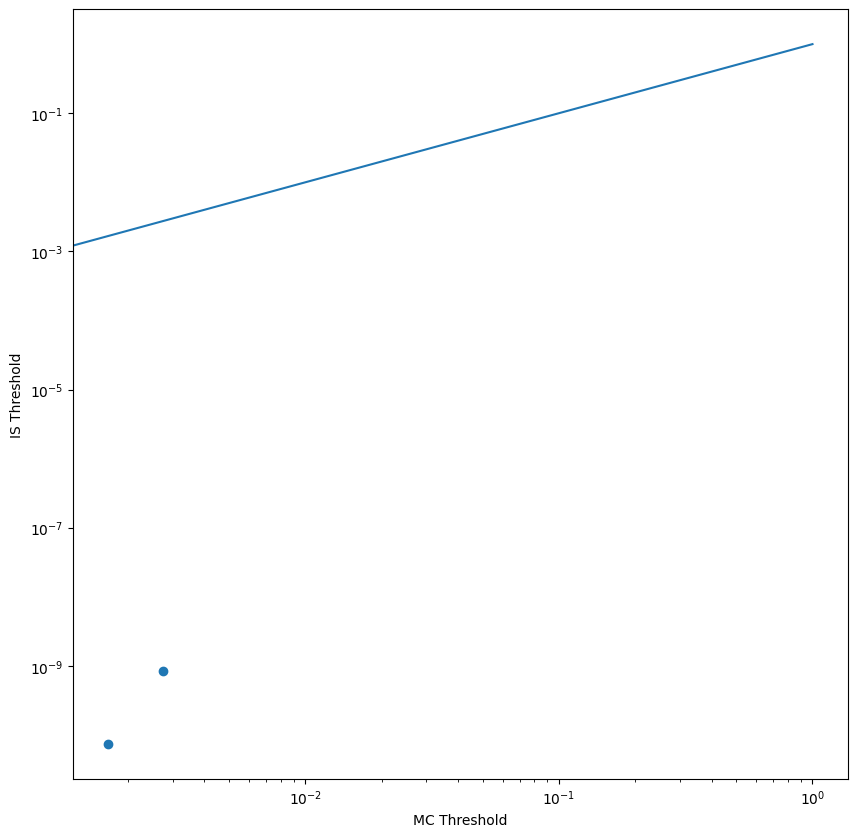

model_outputs/meta-llama-3-8b-instruct
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'ablation_intensity', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 'model_name', 'base_model_name', 'model_idx', 'cheap_judge', 'use_cache', 'save_output', 'smc_verbose', 'output_dir', 'timestamp'])
3 0.5


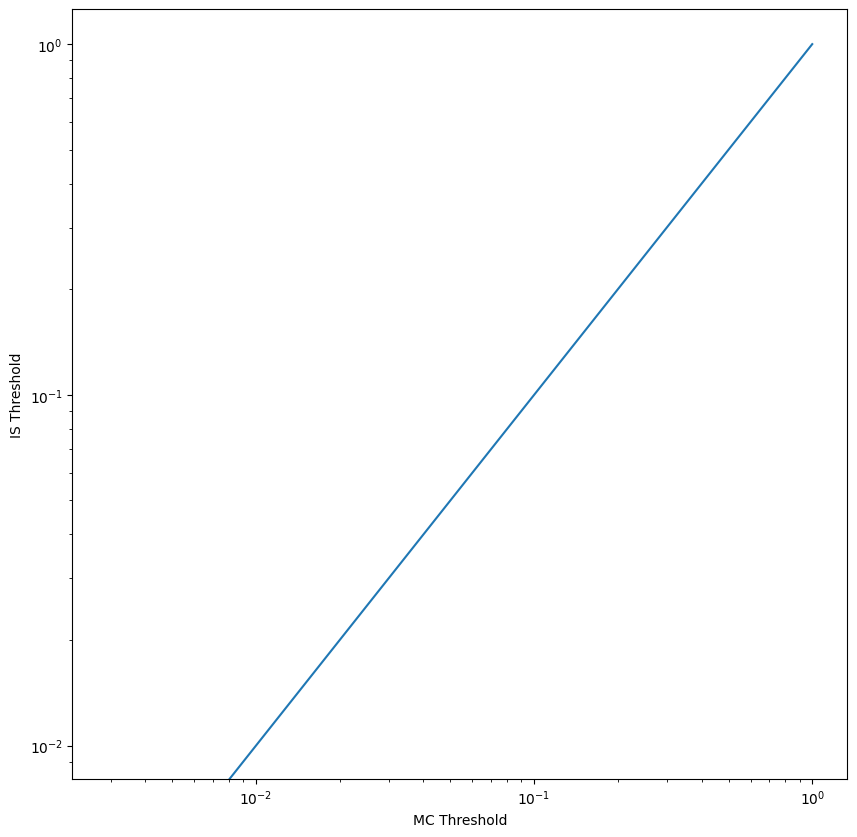

model_outputs/gemma-2-2b-it
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'ablation_intensity', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 'model_name', 'base_model_name', 'model_idx', 'cheap_judge', 'use_cache', 'save_output', 'smc_verbose', 'output_dir', 'timestamp'])
dict_keys(['decoding', 'resample_start', 'resample_end', 'resample_interval', 'lmbda', 'adaptive_resampling', 'adaptive_resampling_threshold', 'base_inv_temperature', 'proposal_inv_temperature', 'proposal_model_switch_idx', 'seed', 'dataset', 'ablation_intensity', 'max_new_tokens', 'num_particle_arr', 'proposal_model', 'base_model_device', 'proposal_model_device', 'reward_fn_device', 'reward_batch_size', 'use_smc', 'm

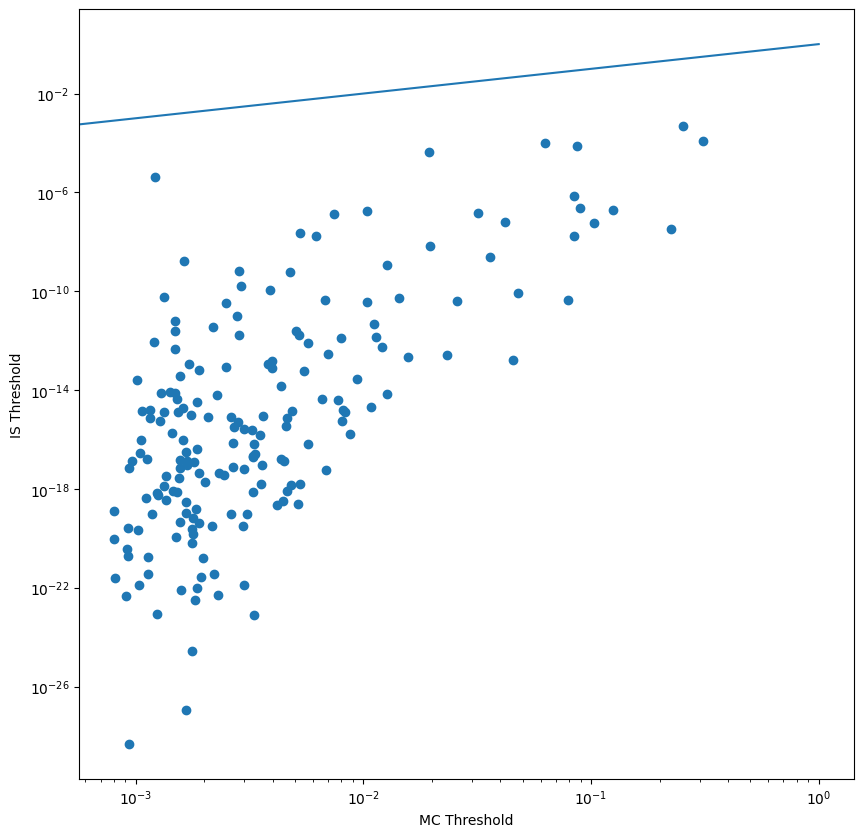

In [17]:
output_path = "./model_outputs"
mc_harm_path = "./monte_carlo_estimates/results/strong_reject/"

model_name_arr = list(Path(output_path).iterdir())

# model_name = "meta-llama-3-8b-instruct"

for model_name in model_name_arr:
    print(model_name)
    
    mc_harm_estimates = load_mc_harm_estimates(mc_harm_path, model_name.name)
    is_model_logs = read_results(
        output_path=output_path,
        model_name=model_name.name,
        mc_harm_estimates=mc_harm_estimates,
    )            

    model_comparison_arr = judge_threshold_ablation(mc_model_logs=mc_harm_estimates, is_model_logs=is_model_logs)

    # make_log_log_plots(model_comparison_arr)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
    ax.scatter(model_comparison_arr['mc_score_mean'], model_comparison_arr['is_score_mean'])
    ax.plot(np.linspace(0, 1, 100), np.linspace(0,1,100))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("MC Threshold")
    ax.set_ylabel("IS Threshold")
    
    plt.show()
    plt.close()